In [141]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np


# Basic characteristics for a plot
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False


In [142]:
# Used for changing the format
def billions_formatter(x, pos):
    return f"{x:,.0f}B"

# Used for changing the format
def billions_formatter2(x, pos):
    return f"{x:,.1f}B"

# Used for changing the format
def percentage(x,pos):
    return f"{x*100:,.0f}%"

# A function that creates a list of colors for eachcompany. The chosen one will have
# a different color
def palette_color(color1,color2,df,df_best):
    return [color2 if df.loc[c]["company_name"] == df_best["company_name"].values[0] 
                       else color1 for c in df.index]

# A function that checks if there is our chosen company or not
def is_in(df,df_best):
    for i in df.index:
        if df.loc[i]["company_name"] == df_best["company_name"].values[0]:
           print("The company is inside the sorted list.")
           return df
    print("The chosen company is not on the list. It's added.")
    return pd.concat([df,df_best])



In [143]:
df = pd.read_csv(r"data\Symbol_Info_extended.csv")

# First of all we do a summary of the features of each table and possible NA values
summary = pd.DataFrame({
    "column" : df.columns,
    "dtype" : df.dtypes.astype(str).values,
    "missing_values" : df.isna().sum().values,
})

print(summary)
print(df.head())


# My Student ID is 1000066172 so we take as country Canada
df_can = df[df["country"] == "Canada"].copy()

# Small check to se if there are values
print(df_can.head())
print("Number of rows : ",df_can.shape[0])

# Creating column market capitalization in billions
df_can["market_cap_b"] = df_can["market_cap"]/1e9



              column    dtype  missing_values
0             symbol   object               0
1       company_name   object              99
2             sector   object             101
3           industry   object             101
4            country   object             100
5         market_cap  float64             100
6         net_income  float64             106
7      total_revenue  float64             187
8   return_on_assets  float64             119
9   return_on_equity  float64             262
10    profit_margins  float64             100
11       pe_trailing  float64             975
12        pe_forward  float64             165
13   earnings_growth  float64            1284
14    price_to_sales  float64             190
15     price_to_book  float64              96
16    revenue_growth  float64             222
17    debt_to_equity  float64             542
18    dividend_yield  float64            1480
19      payout_ratio  float64             103
20     free_cashflow  float64     

## Step 0


In [144]:
# We want to select the company corresponding to the median in market capitalization 
# But we want to select it among the most numerous industry
df_best = df_can[df_can["industry"] == df_can.groupby("industry").count()["symbol"].idxmax()]
df_best = df_best[(df_best["market_cap"] == df_best["market_cap"].median())]
print(f"Selected Company: {df_best["company_name"].values[0]}")


Selected Company: Alamos Gold Inc.


## Step 1


In [145]:
# Taking only the features that matter for the analysis
df_analysis = df_can[["symbol", "company_name", "sector", "industry", "country", "market_cap","return_on_assets", "return_on_equity", "profit_margins","pe_trailing", "price_to_book", "revenue_growth", "debt_to_equity", "free_cashflow","market_cap_b"]].copy()

# Replacing infinite values with NaN
df_analysis = df_analysis.replace([np.inf, -np.inf], np.nan)

# Taking only firms with a positive market capitalization
df_analysis = df_analysis[(df_analysis["market_cap"] > 0)]

#Assessing if there are negative values for pe trailing and price to book
df_negative_pe = df_analysis[df_analysis["pe_trailing"]<0]
df_negative_price = df_analysis[df_analysis["price_to_book"]<0]
print(f"Number of negative pe_trailing: {df_negative_pe.shape[0]}\nNumber of negative pe_trailing: {df_negative_price.shape[0]}\n")

# Substituting negative values with NaN values
df_analysis.loc[df_analysis["pe_trailing"]<0, "pe_trailing"] = np.nan
df_analysis.loc[df_analysis["price_to_book"]<0, "price_to_book"] = np.nan

# Check if the code does it
df_negative_pe = df_analysis[df_analysis["pe_trailing"]<0]
df_negative_price = df_analysis[df_analysis["price_to_book"]<0]
print(f"Number of negative pe_trailing: {df_negative_pe.shape[0]}\nNumber of negative pe_trailing: {df_negative_price.shape[0]}")

# 
df_analysis["company_name"] = df_analysis["company_name"].fillna("Unknow")


Number of negative pe_trailing: 0
Number of negative pe_trailing: 3

Number of negative pe_trailing: 0
Number of negative pe_trailing: 0


## Step 2


The company is inside the sorted list.


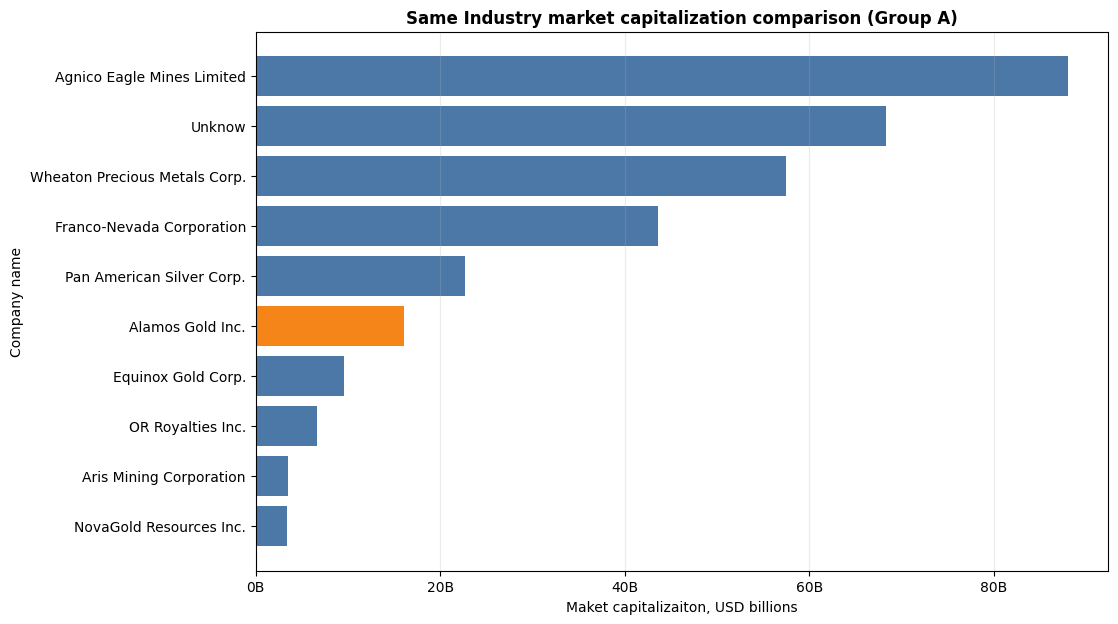

In [146]:
# Group A

# Selecting the same industry of the chosen company
df_industry = df_analysis[df_analysis["industry"] == str(df_best["industry"].values[0])].copy()

# Sorting 
df_industry = df_industry.nlargest(10,"market_cap_b")
df_industry = df_industry.sort_values("market_cap_b",ascending = True)

# Checking if it is inside
df_industry = is_in(df_industry,df_best)

# Creating a bar plot to compare them
fig, ax = plt.subplots(figsize = (11,7))

# Plotting and formatting
ax.barh(
    df_industry["company_name"],
    df_industry["market_cap_b"],
    color = palette_color("#4C78A8","#F58518",df_industry,df_best)
    )
ax.set_title("Same Industry market capitalization comparison (Group A)")
ax.set_xlabel("Maket capitalizaiton, USD billions")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.set_ylabel("Company name")
ax.grid(axis="x",alpha = 0.25)



The chosen company is not on the list. It's added.


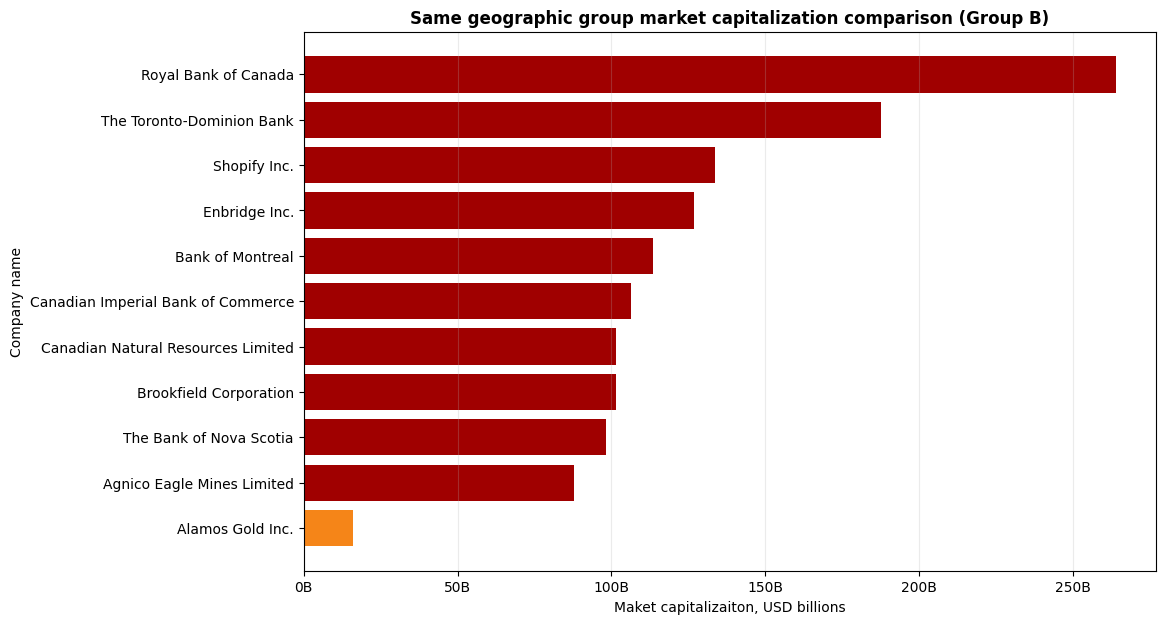

In [147]:
# Group B

# Sorting by market capitalization company for same geographic group
df_sort_geo = df_analysis.nlargest(10,"market_cap_b")

# Seeing if the company is not on the list. If it is not, add it
df_sort_geo = is_in(df_sort_geo,df_best)

# Sorting all 
df_sort_geo = df_sort_geo.sort_values("market_cap_b",ascending = True)

# Creating a bar plot to compare them
fig, ax = plt.subplots(figsize = (11,7))

# Plotting and formatting
ax.barh(
    df_sort_geo["company_name"],
    df_sort_geo["market_cap_b"],
    color = palette_color("#a00000","#F58518",df_sort_geo,df_best)
    )
ax.set_title("Same geographic group market capitalization comparison (Group B)")
ax.set_xlabel("Maket capitalizaiton, USD billions")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.set_ylabel("Company name")
ax.grid(axis="x",alpha = 0.25)


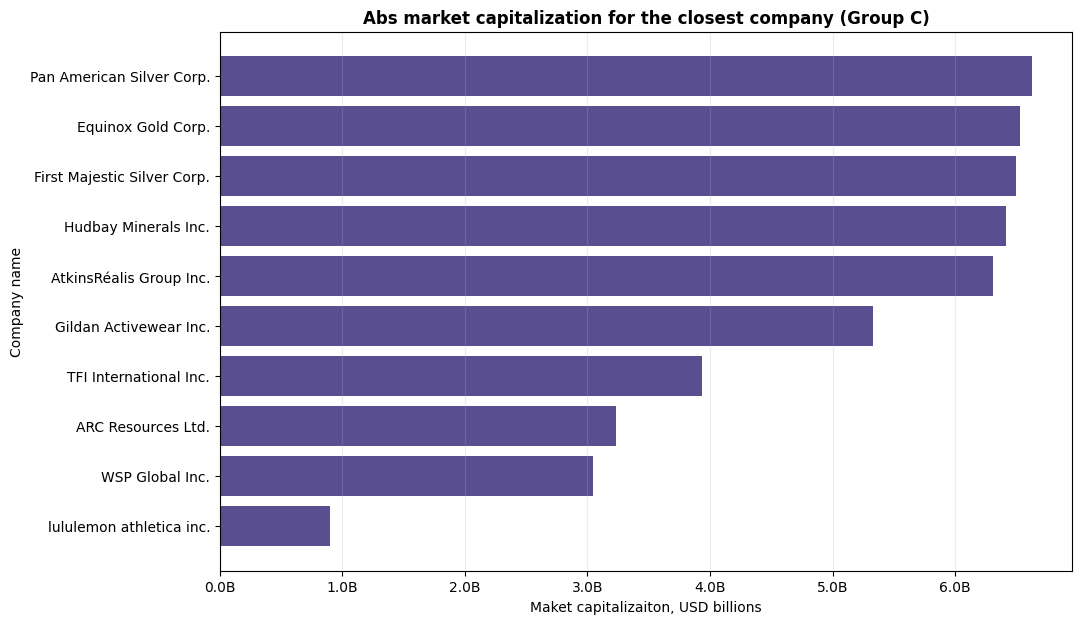

In [148]:
# Group C

# Creating a new dataframe in which there is another feature that containse the
# absolute deviation from the market capitalization of the refered company 
df_abs = df_analysis.copy()
df_abs["abs"] = df_abs["market_cap_b"].apply(lambda c : abs(c-df_best["market_cap_b"].values[0])) 


# Sorting 
df_abs = df_abs.nsmallest(n = 11,columns = "abs",keep = "all")
df_abs = df_abs.sort_values("abs",ascending=True)

# Dropping the chosen company
df_abs_clean = df_abs.drop(df_abs[df_abs["company_name"] == str(df_best["company_name"].values[0])].index).copy()

# Creating a bar plot to compare them
fig, ax = plt.subplots(figsize = (11,7))

# Plotting and formatting
ax.barh(
    df_abs_clean["company_name"],
    df_abs_clean["abs"],
    color = "#594e90"
    )
ax.set_title("Abs market capitalization for the closest company (Group C)")
ax.set_xlabel("Maket capitalizaiton, USD billions")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter2))
ax.set_ylabel("Company name")
ax.grid(axis="x",alpha = 0.25)


## Step 3


Text(0, 0.5, 'Company')

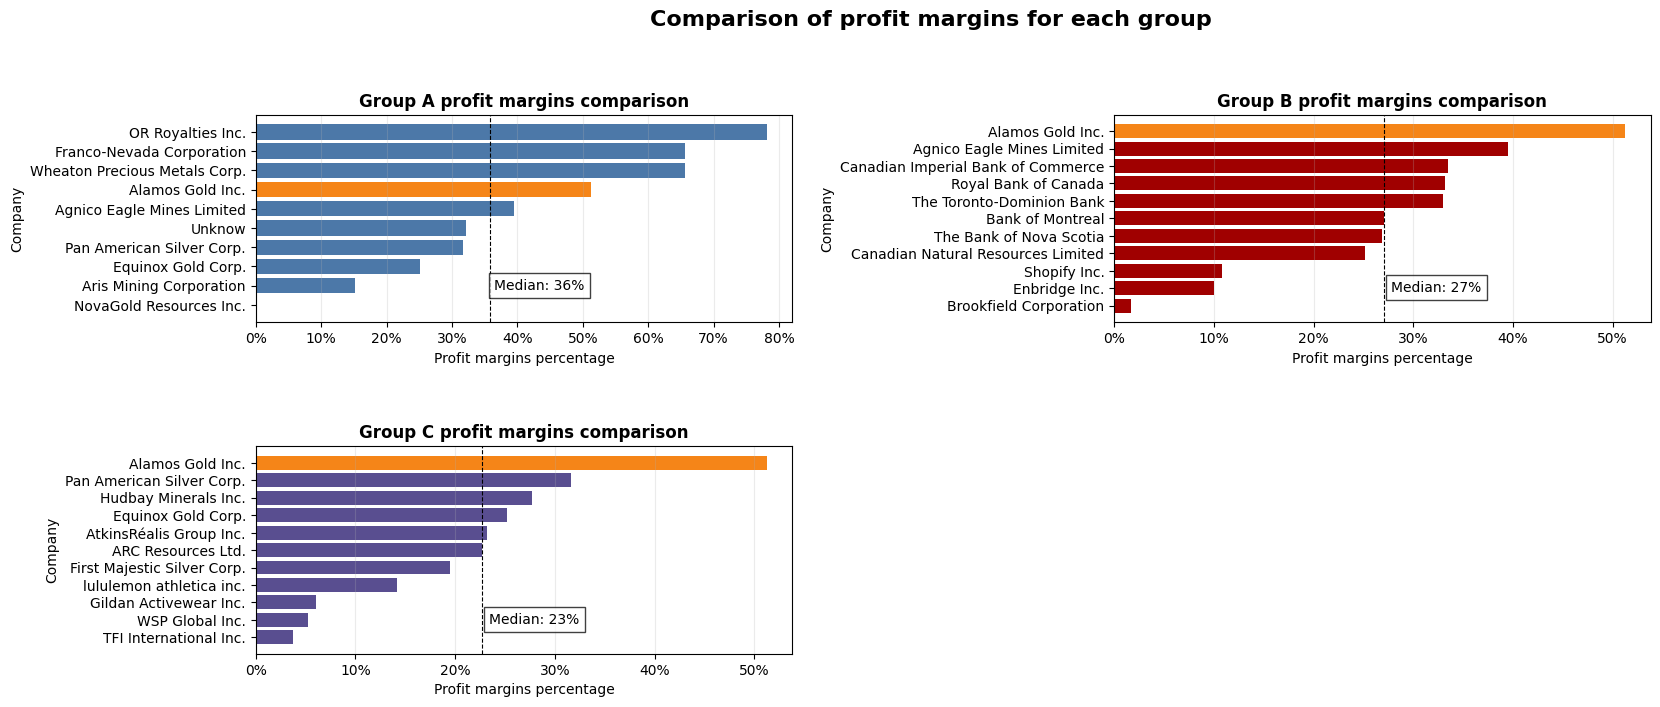

In [149]:
# Creating the graph by a 2x2 subplots
fig, ax = plt.subplots(
    nrows = 2,
    ncols = 2,
    figsize=(18,7)
)

# Some properties for a better visualization of the plots
plt.subplots_adjust(hspace=0.6, wspace=0.6)

# The general title
fig.suptitle(
    "Comparison of profit margins for each group",
    fontsize=16,
    fontweight="bold",
    y=1.03
)


# Dividing in three subplots and deleting the fourth
ax1 = ax[0][0]
ax2 = ax[0][1]
ax3 = ax[1][0]
ax[1][1].axis("off")


# Chosing proft margins as metric for the group A
df_profit_A = df_industry[["profit_margins","company_name"]].copy()
df_profit_A = df_profit_A.dropna().sort_values("profit_margins",ascending = True)


# Creating the plot
ax1.barh(
    df_profit_A["company_name"],
    df_profit_A["profit_margins"],
    color = palette_color("#4C78A8","#F58518",df_profit_A,df_best)
)
ax1.grid(axis = "x",alpha = 0.25)
ax1.set_title("Group A profit margins comparison")
ax1.xaxis.set_major_formatter(FuncFormatter(percentage))
ax1.set_xlabel("Profit margins percentage")
ax1.set_ylabel("Company")
ax1.axvline(df_profit_A["profit_margins"].median(), color="black", linewidth=0.8,linestyle = "--")
ax1.text(df_profit_A["profit_margins"].median()+0.007, 0.80, f"Median: {df_profit_A["profit_margins"].median()*100:,.0f}%", fontsize=10, ha="left", bbox=dict(facecolor="white", alpha=0.75, edgecolor="black"))




# Chosing proft margins as metric for the group B
df_profit_B = df_sort_geo[["profit_margins","company_name"]].copy()
df_profit_B = df_profit_B.dropna().sort_values("profit_margins",ascending = True)

# Creating the plot
ax2.barh(
    df_profit_B["company_name"],
    df_profit_B["profit_margins"],
    color = palette_color("#a00000","#F58518",df_profit_B,df_best)
)
ax2.grid(axis="x",alpha=0.25)
ax2.axvline(df_profit_B["profit_margins"].median(), color="black", linewidth=0.8,linestyle = "--")
ax2.text(df_profit_B["profit_margins"].median()+0.007, 0.80, f"Median: {df_profit_B["profit_margins"].median()*100:,.0f}%", fontsize=10, ha="left", bbox=dict(facecolor="white", alpha=0.75, edgecolor="black"))
ax2.set_title("Group B profit margins comparison")
ax2.xaxis.set_major_formatter(FuncFormatter(percentage))
ax2.set_xlabel("Profit margins percentage")
ax2.set_ylabel("Company")




# Chosing proft margins as a metric for the group C
df_profit_C = df_abs[["profit_margins","company_name"]].copy()
df_profit_C = df_profit_C.dropna().sort_values("profit_margins",ascending = True)

# Creating the plot
ax3.barh(
    df_profit_C["company_name"],
    df_profit_C["profit_margins"],
    color = palette_color("#594e90","#F58518",df_profit_C,df_best)
)
ax3.grid(axis="x",alpha=0.25)
ax3.axvline(df_profit_C["profit_margins"].median(), color="black", linewidth=0.8,linestyle = "--")
ax3.text(df_profit_C["profit_margins"].median()+0.007, 0.80, f"Median: {df_profit_C["profit_margins"].median()*100:,.0f}%", fontsize=10, ha="left", bbox=dict(facecolor="white", alpha=0.75, edgecolor="black"))
ax3.set_title("Group C profit margins comparison")
ax3.xaxis.set_major_formatter(FuncFormatter(percentage))
ax3.set_xlabel("Profit margins percentage")
ax3.set_ylabel("Company")


Text(0, 0.5, 'Company')

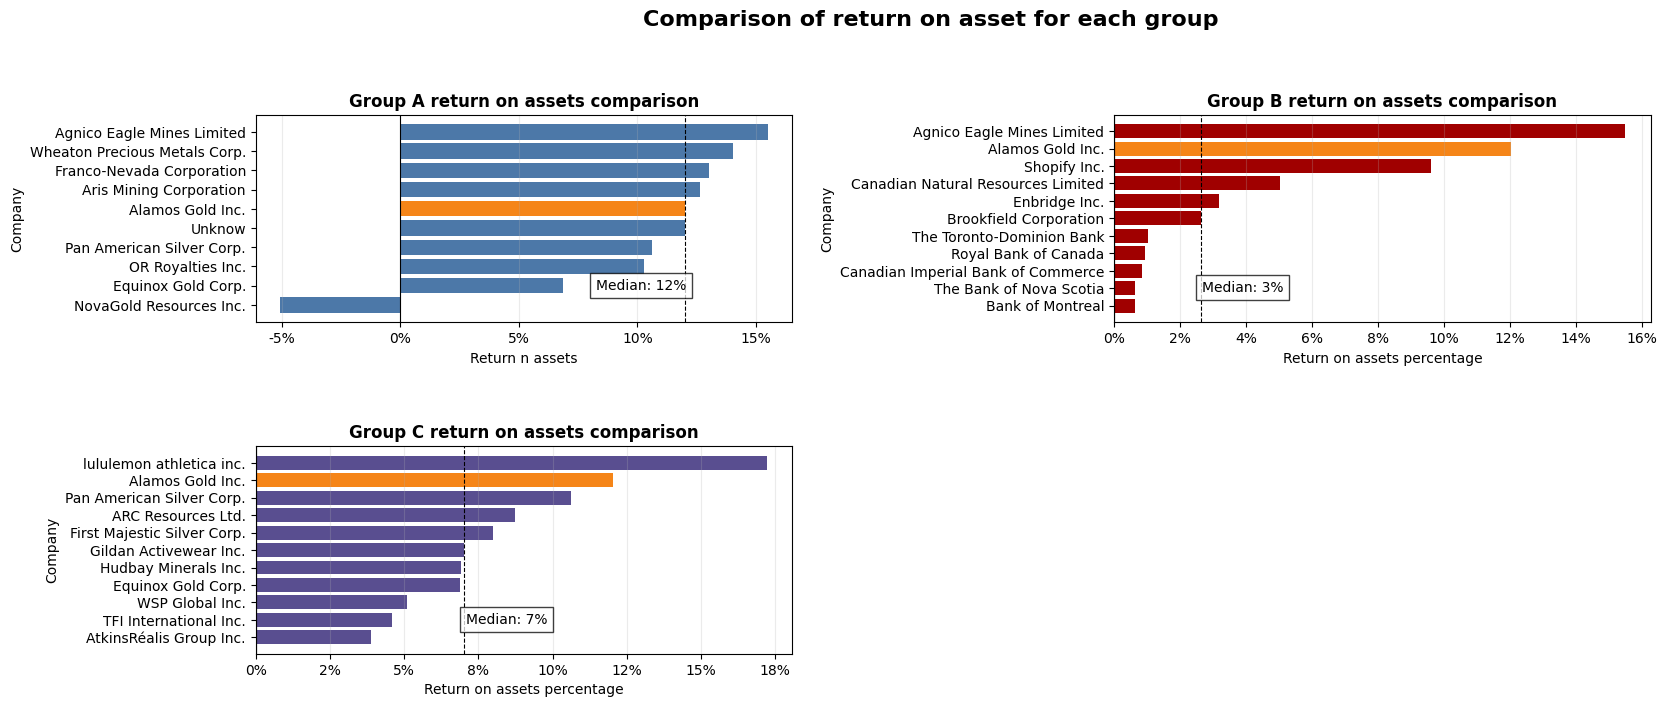

In [150]:
fig, ax = plt.subplots(
    nrows = 2,
    ncols = 2,
    figsize=(18,7)
)

# Some properties for a better visualization of the plots
plt.subplots_adjust(hspace=0.6, wspace=0.6)

# The general title
fig.suptitle(
    "Comparison of return on asset for each group",
    fontsize=16,
    fontweight="bold",
    y=1.03
)


# Dividing in three subplots and deleting the fourth
ax1 = ax[0][0]
ax2 = ax[0][1]
ax3 = ax[1][0]
ax[1][1].axis("off")


# Chosing proft margins as metric for the group A
df_return_A = df_industry[["return_on_assets","company_name"]].copy()
df_return_A = df_return_A.dropna().sort_values("return_on_assets",ascending = True)


# Creating the plot
ax1.barh(
    df_return_A["company_name"],
    df_return_A["return_on_assets"],
    color = palette_color("#4C78A8","#F58518",df_return_A,df_best)
)
ax1.grid(axis = "x",alpha = 0.25)
ax1.set_title("Group A return on assets comparison")
ax1.xaxis.set_major_formatter(FuncFormatter(percentage))
ax1.set_xlabel("Return n assets")
ax1.set_ylabel("Company")
ax1.axvline(0,color="black", linewidth=0.8)
ax1.axvline(df_return_A["return_on_assets"].median(), color="black", linewidth=0.8,linestyle = "--")
ax1.text(df_return_A["return_on_assets"].median()+0.0005, 0.80, f"Median: {df_return_A["return_on_assets"].median()*100:,.0f}%", fontsize=10, ha="right", bbox=dict(facecolor="white", alpha=0.75, edgecolor="black"))




# Chosing proft margins as metric for the group B
df_return_B = df_sort_geo[["return_on_assets","company_name"]].copy()
df_return_B = df_return_B.dropna().sort_values("return_on_assets",ascending = True)

# Creating the plot
ax2.barh(
    df_return_B["company_name"],
    df_return_B["return_on_assets"],
    color = palette_color("#a00000","#F58518",df_return_B,df_best)
)
ax2.grid(axis="x",alpha=0.25)
ax2.axvline(df_return_B["return_on_assets"].median(), color="black", linewidth=0.8,linestyle = "--")
ax2.text(df_return_B["return_on_assets"].median()+0.0001, 0.80, f"Median: {df_return_B["return_on_assets"].median()*100:,.0f}%", fontsize=10, ha="left", bbox=dict(facecolor="white", alpha=0.75, edgecolor="black"))
ax2.axvline(0,color="black", linewidth=0.8)
ax2.set_title("Group B return on assets comparison")
ax2.xaxis.set_major_formatter(FuncFormatter(percentage))
ax2.set_xlabel("Return on assets percentage")
ax2.set_ylabel("Company")




# Chosing proft margins as a metric for the group C
df_return_C = df_abs[["return_on_assets","company_name"]].copy()
df_return_C = df_return_C.dropna().sort_values("return_on_assets",ascending = True)

# Creating the plot
ax3.barh(
    df_return_C["company_name"],
    df_return_C["return_on_assets"],
    color = palette_color("#594e90","#F58518",df_return_C,df_best)
)
ax3.grid(axis="x",alpha=0.25)
ax3.axvline(df_return_C["return_on_assets"].median(), color="black", linewidth=0.8,linestyle = "--")
ax3.axvline(0,color="black", linewidth=0.8)
ax3.text(df_return_C["return_on_assets"].median()+0.0007, 0.80, f"Median: {df_return_C["return_on_assets"].median()*100:,.0f}%", fontsize=10, ha="left", bbox=dict(facecolor="white", alpha=0.75, edgecolor="black"))
ax3.set_title("Group C return on assets comparison")
ax3.xaxis.set_major_formatter(FuncFormatter(percentage))
ax3.set_xlabel("Return on assets percentage")
ax3.set_ylabel("Company")


## Step 4

Text(0, 0.5, 'Company')

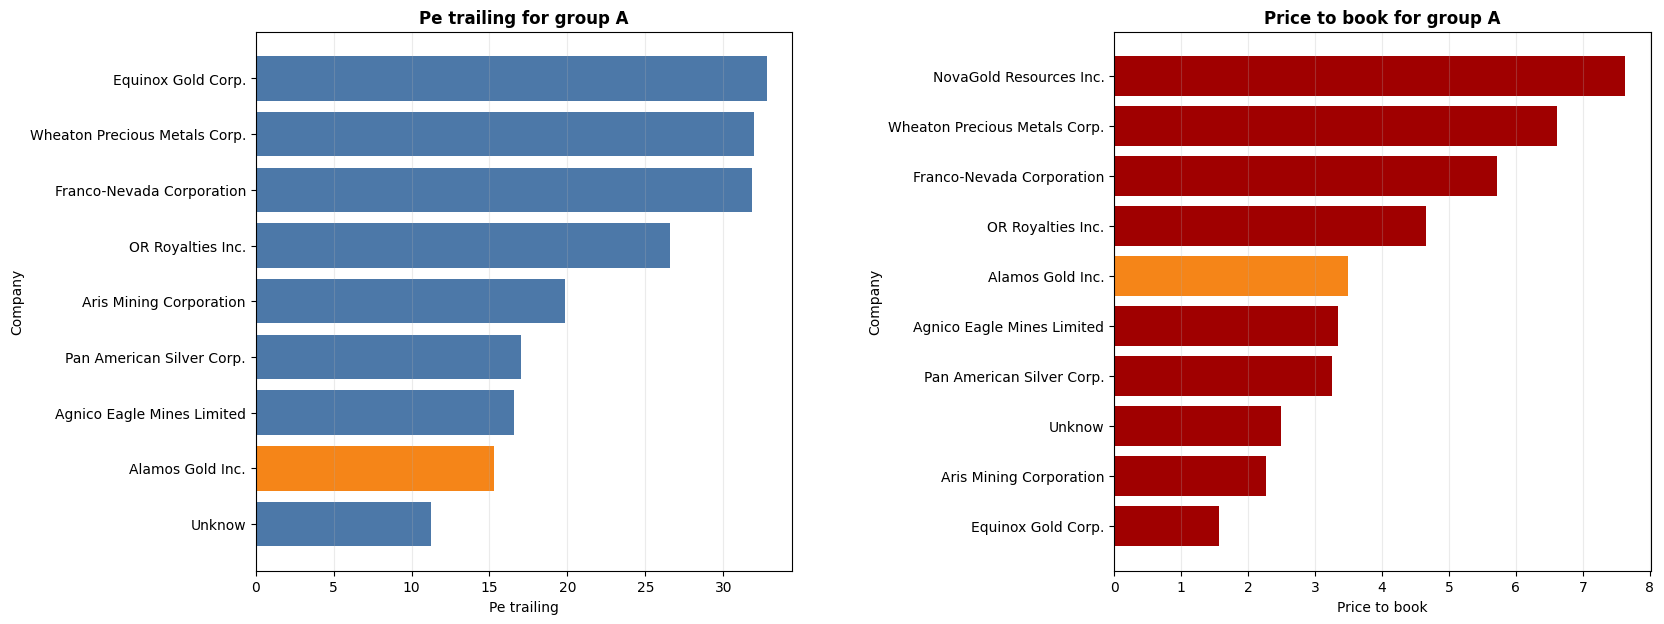

In [151]:
# Creating the plots
fig, ax = plt.subplots(
    nrows =  1,
    ncols = 2,
    figsize=(18,7)
)

# Some properties for a better visualization of the plots
plt.subplots_adjust(hspace=0.6, wspace=0.6)
ax1 = ax[0]
ax2 = ax[1]

# Sorting for pe_trailing
df_A  = df_industry[["pe_trailing","price_to_book","company_name"]].copy()
df_A = df_A.sort_values("pe_trailing",ascending = True)


# Plotting
ax1.barh(
    df_A["company_name"],
    df_A["pe_trailing"],
    color = palette_color("#4C78A8","#F58518",df_A,df_best)
)
ax1.grid(axis = "x",alpha = 0.25)
ax1.set_title("Pe trailing for group A")
ax1.set_xlabel("Pe trailing")
ax1.set_ylabel("Company")

# Sorting for price_to_book
df_A = df_A.sort_values("price_to_book",ascending = True)
ax2.barh(
    df_A["company_name"],
    df_A["price_to_book"],
    color = palette_color("#a00000","#F58518",df_A,df_best)
)
ax2.grid(axis = "x",alpha = 0.25)
ax2.set_title("Price to book for group A")
ax2.set_xlabel("Price to book")
ax2.set_ylabel("Company")


Text(0.2735, 0.8, 'Median: 0.3')

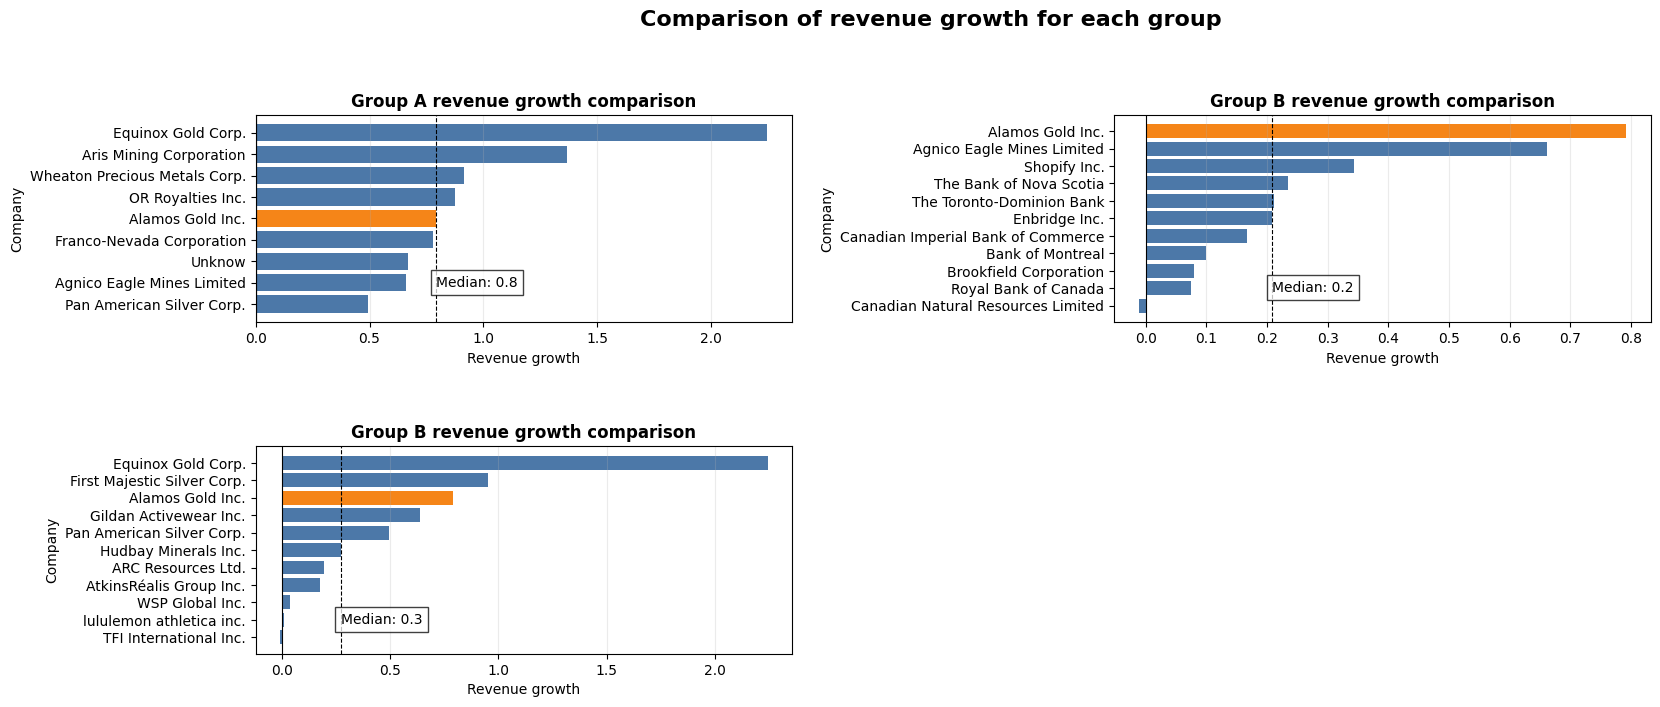

In [163]:
fig, ax = plt.subplots(
    nrows = 2,
    ncols = 2,
    figsize=(18,7)
)

# Some properties for a better visualization of the plots
plt.subplots_adjust(hspace=0.6, wspace=0.6)

# The general title
fig.suptitle(
    "Comparison of revenue growth for each group",
    fontsize=16,
    fontweight="bold",
    y=1.03
)


# Dividing in three subplots and deleting the fourth
ax1 = ax[0][0]
ax2 = ax[0][1]
ax3 = ax[1][0]
ax[1][1].axis("off")


# Chosing proft margins as metric for the group A
df_revenue_A = df_industry[["revenue_growth","company_name"]].copy()
df_revenue_A = df_revenue_A.dropna().sort_values("revenue_growth",ascending = True)


# Creating the plot
ax1.barh(
    df_revenue_A["company_name"],
    df_revenue_A["revenue_growth"],
    color = palette_color("#4C78A8","#F58518",df_revenue_A,df_best)
)
ax1.grid(axis = "x",alpha = 0.25)
ax1.set_title("Group A revenue growth comparison")
ax1.set_xlabel("Revenue growth")
ax1.set_ylabel("Company")
ax1.axvline(0,color="black", linewidth=0.8)
ax1.axvline(df_revenue_A["revenue_growth"].median(), color="black", linewidth=0.8,linestyle = "--")
ax1.text(df_revenue_A["revenue_growth"].median()+0.0005, 0.80, f"Median: {df_revenue_A["revenue_growth"].median():,.1f}", fontsize=10, ha="left", bbox=dict(facecolor="white", alpha=0.75, edgecolor="black"))




# Chosing proft margins as metric for the group B
df_revenue_B = df_sort_geo[["revenue_growth","company_name"]].copy()
df_revenue_B = df_revenue_B.dropna().sort_values("revenue_growth",ascending = True)

# Creating the plot
ax2.barh(
    df_revenue_B["company_name"],
    df_revenue_B["revenue_growth"],
    color = palette_color("#4C78A8","#F58518",df_revenue_B,df_best)
)
ax2.grid(axis = "x",alpha = 0.25)
ax2.set_title("Group B revenue growth comparison")
ax2.set_xlabel("Revenue growth")
ax2.set_ylabel("Company")
ax2.axvline(0,color="black", linewidth=0.8)
ax2.axvline(df_revenue_B["revenue_growth"].median(), color="black", linewidth=0.8,linestyle = "--")
ax2.text(df_revenue_B["revenue_growth"].median()+0.0005, 0.80, f"Median: {df_revenue_B["revenue_growth"].median():,.1f}", fontsize=10, ha="left", bbox=dict(facecolor="white", alpha=0.75, edgecolor="black"))




# Chosing proft margins as a metric for the group C
df_revenue_C = df_abs[["revenue_growth","company_name"]].copy()
df_revenue_C = df_revenue_C.dropna().sort_values("revenue_growth",ascending = True)

# Creating the plot
ax3.barh(
    df_revenue_C["company_name"],
    df_revenue_C["revenue_growth"],
    color = palette_color("#4C78A8","#F58518",df_revenue_C,df_best)
)
ax3.grid(axis = "x",alpha = 0.25)
ax3.set_title("Group B revenue growth comparison")
ax3.set_xlabel("Revenue growth")
ax3.set_ylabel("Company")
ax3.axvline(0,color="black", linewidth=0.8)
ax3.axvline(df_revenue_C["revenue_growth"].median(), color="black", linewidth=0.8,linestyle = "--")
ax3.text(df_revenue_C["revenue_growth"].median()+0.0005, 0.80, f"Median: {df_revenue_C["revenue_growth"].median():,.1f}", fontsize=10, ha="left", bbox=dict(facecolor="white", alpha=0.75, edgecolor="black"))


